In [ ]:
import os 
import gc

import torch
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam
from copy import deepcopy

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

import sqlite3
import pandas as pd

import subprocess
from datetime import datetime

import ipywidgets as widgets
from IPython.display import display

import time

import json 

from pathlib import Path
import sys

ROOT = Path.cwd().parents[1]
sys.path.append(str(ROOT))

from src.config.paths import DB_PATH, MODELS
from src.model_selection import get_checkpoints, load_inference_models, create_model_selector
from src.fine_tune.utils import get_device


MODEL_DIR = MODELS / "category_head"
os.makedirs(MODEL_DIR, exist_ok=True)

In [3]:
DINO_DIR = MODELS / "dino_fine_tune"

dino_checkpoints = get_checkpoints(DINO_DIR)

print(f"Found {len(dino_checkpoints)} fine-tuned DINO checkpoints")

Found 1 fine-tuned DINO checkpoints


In [ ]:
selector = create_model_selector(dino_checkpoints=dino_checkpoints)

selector.display()

Dropdown(description='DINO:', layout=Layout(width='800px'), options=(('Select a DINO model', 'UNSELECTED'), ('…

Button(button_style='success', description='Confirm selection', layout=Layout(width='180px'), style=ButtonStyl…

Output()

In [6]:
device = get_device()

selected_path = selector.get_selected_path()

pipeline = load_inference_models(selected_path, device=device)

2.12.0+cu130
13.0
True
1
Device: cuda


Using cache found in /home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Loading DINO: /home/ciaran/Projects/bursary/UL-Summer-Bursary-2026/models/dino_fine_tune/20260731_164405/model.pt


In [7]:
conn = sqlite3.connect(DB_PATH)

df = pd.read_sql_query("""
    SELECT path, split
    FROM meta
""", conn)

categories = pd.read_sql_query("SELECT DISTINCT category FROM meta", conn)["category"].to_list()

conn.close()

train_paths = df[df["split"] == "train"]["path"].to_list()
test_paths = df[df["split"] != "train"]["path"].to_list()

In [8]:
%load_ext autoreload
%autoreload 0

from src.fine_tune import ModelData, ProjectionHead, BatchSampler, contrastive_transform, test_transform
from src.fine_tune.train import train_one_epoch, evaluate
from src.fine_tune.losses.category_head.combined_loss import CombinedLoss

git_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    text=True
).strip()


In [9]:
LOSSES = {
    "category_cont" : True,
    "preservation": True
}

WEIGHTS = {
    "category_cont" : 1.0,
    "preservation": 0.5
}

NOTES = [
    "Trained using fine-tuned dino"
]

In [10]:
SEED = 42

NUM_WORKERS = 8
PIN_MEMORY = device.type == "cuda"
SAMPLES_PER_CATEGORY = 16

BATCH_SIZE = len(categories) * SAMPLES_PER_CATEGORY

EPOCHS = 20

DIM = 384
HIDDEN_DIM = 768

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

MODEL_NORMALISER = "layer"

MODEL_NAME = "model.pt"

In [ ]:
MODEL_INFO = {
    "losses" : LOSSES,
    "weights" : WEIGHTS,
    "notes" : NOTES,
    "git_commit" : git_commit,
    "parameters" : {
        "batch_size" : 256,
        "epochs" : EPOCHS,
        "samples_per_category" : SAMPLES_PER_CATEGORY,

        "model_dim" : DIM,
        "hidden_dim": HIDDEN_DIM,
        "model_normaliser": MODEL_NORMALISER,

        "learning_rate" : LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        
        "num_workers" : NUM_WORKERS,
        "pin_memory" : PIN_MEMORY,

        "random_seed" : SEED
    },
    "parent_models" : {
        "dino": str(pipeline.dino_stage.path) if pipeline.dino_stage.path is not None else None
    }
}

In [12]:
category_to_id = {category: idx for idx, category in enumerate(categories)}

dataset = ModelData(train_paths, root=ROOT, category_to_id=category_to_id, transform=contrastive_transform)
test_set = ModelData(test_paths, root=ROOT, category_to_id=category_to_id, transform=test_transform)

train_split = int(len(dataset) * 0.95)
val_split = len(dataset) - train_split

generator = torch.Generator().manual_seed(SEED)

train_set, val_set = random_split(
    dataset,
    [train_split, val_split],
    generator=generator
)

train_labels = [dataset.category_ids[i] for i in train_set.indices]
val_labels = [dataset.category_ids[i] for i in val_set.indices]

train_sampler = BatchSampler(
    labels=train_labels,
    samples_per_cat=SAMPLES_PER_CATEGORY,
    seed=None
)

val_sampler = BatchSampler(
    labels=val_labels,
    samples_per_cat=SAMPLES_PER_CATEGORY,
    seed=SEED
)

train_loader = DataLoader(
    train_set,
    batch_sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_set,
    batch_sampler=val_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [13]:
model = ProjectionHead(dim=DIM, hidden_dim=HIDDEN_DIM, norm_type=MODEL_NORMALISER).to(device)

optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = CombinedLoss(enabled=LOSSES, weights=WEIGHTS)

In [14]:
step_display = display(
    pd.DataFrame(),
    display_id=True
)

epoch_display = display(
    pd.DataFrame(),
    display_id=True
)

""


""


In [ ]:
results = pd.DataFrame(columns=["epoch", "train_loss", "val_loss", "gap", "time"])

best_val = float("inf")
best_state = None

pbar = tqdm(total=EPOCHS, desc="Training")

table_out = widgets.Output()
display(table_out)

try:
    for epoch in range(EPOCHS):
        start = time.perf_counter()

        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, pipeline)
        val_loss = evaluate(model, val_loader, criterion, device, pipeline)

        elapsed_time = time.perf_counter() - start

        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())
            
        results.loc[len(results)] = {
            "epoch": epoch+1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "gap": abs(val_loss - train_loss),
            "time": elapsed_time
        }
        
        with table_out:
            table_out.clear_output(wait=True) # pyright: ignore[reportUnknownMemberType]
            display(results.style.hide(axis="index"))
        pbar.update(1)

finally:
    pbar.close()

    if best_state is not None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        EXP_DIR = MODEL_DIR / timestamp
        
        os.makedirs(EXP_DIR, exist_ok=False)

        checkpoint = {
            "model_state_dict" : best_state,
            "parameters" : MODEL_INFO["parameters"],
            "parent_models" : MODEL_INFO["parent_models"]
        }

        torch.save(checkpoint, EXP_DIR / MODEL_NAME)

        with open(EXP_DIR / "metadata.json", "w") as f:
            json.dump(MODEL_INFO, f, indent=4)

        results.to_csv(EXP_DIR / "train_history.csv", index=False)
        
        print(f"Best Model Saved (val_loss={best_val:.4f})")

    del model
    del pipeline
    del optimizer
    del criterion

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Output()

Best Model Saved (val_loss=3.4374)


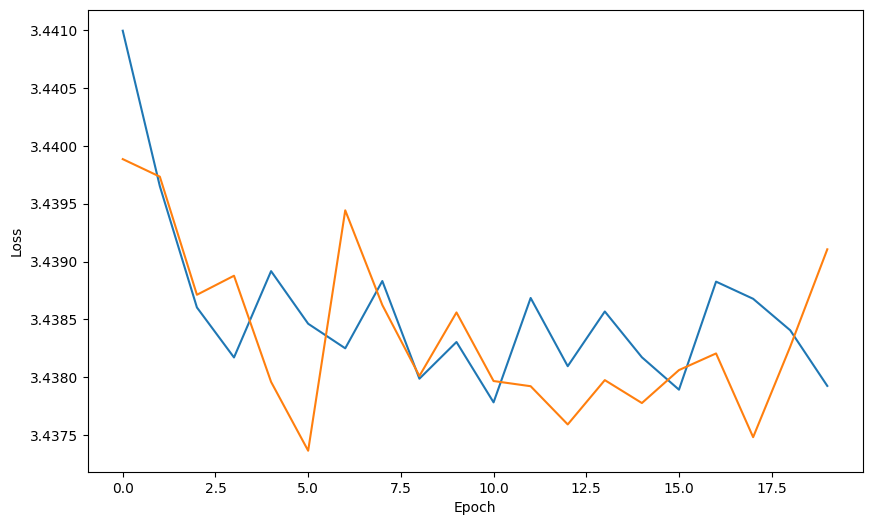

In [16]:
fig = plt.figure(figsize=(10, 6))

plt.plot(range(EPOCHS), results["train_loss"])
plt.plot(range(EPOCHS), results["val_loss"])

plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.show()